# 05 - Initial Analysis: Production, Quality, Maintenance

**Stage 4 of the project.**

With clean, feature-engineered data sitting in `datasets/processed/` (and,
in a real deployment, in the MySQL views from notebook 04), this notebook
does the first pass of exploratory analysis for each of the three domains
this project covers. Every section ends with a chart, because a number
alone rarely tells you *where* to act -- a chart does.

> **Note on data source:** these notebooks read directly from
> `datasets/processed/*.csv` rather than querying MySQL, so the whole
> project can be reviewed and re-run on GitHub (e.g. in Colab/Binder)
> without needing a database server. In a real deployment, swap the
> `pd.read_csv(...)` calls below for `pd.read_sql("SELECT * FROM
> vw_fact_production_injection_molding", engine)` against the views
> created in notebook 04 -- the analysis code itself does not change.

> **Column hiding:** every table loaded below carries 20-35 columns, most
> of which are irrelevant to any single chart. Rather than displaying
> full wide frames, each section below selects only the columns that
> section actually needs -- *"information that doesn't help you, gets in
> your way."*


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

PROCESSED = '../../datasets/processed'
REPORTS = '../../reports'
import os
os.makedirs(REPORTS, exist_ok=True)

prod = pd.read_csv(f'{PROCESSED}/fact_production_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
downtime = pd.read_csv(f'{PROCESSED}/fact_downtime_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
matcons = pd.read_csv(f'{PROCESSED}/fact_material_consumption_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])

cap_var = pd.read_csv(f'{PROCESSED}/fact_cap_inspection_variable_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
cap_attr = pd.read_csv(f'{PROCESSED}/fact_cap_attribute_inspection_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
cap_disp = pd.read_csv(f'{PROCESSED}/fact_cap_disposition_lot_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
bottle_var = pd.read_csv(f'{PROCESSED}/fact_bottle_inspection_variables_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
bottle_attr = pd.read_csv(f'{PROCESSED}/fact_bottle_attribute_inspection_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
bottle_disp = pd.read_csv(f'{PROCESSED}/fact_bottle_disposition_lot_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
ink_attr = pd.read_csv(f'{PROCESSED}/fact_ink_attribute_inspection_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
ink_disp = pd.read_csv(f'{PROCESSED}/fact_ink_disposition_lot_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])

print("Loaded:", {n: d.shape for n, d in {
    'prod': prod, 'downtime': downtime, 'matcons': matcons,
    'cap_var': cap_var, 'cap_attr': cap_attr, 'cap_disp': cap_disp,
    'bottle_var': bottle_var, 'bottle_attr': bottle_attr, 'bottle_disp': bottle_disp,
    'ink_attr': ink_attr, 'ink_disp': ink_disp,
}.items()})


Loaded: {'prod': (9110, 32), 'downtime': (21809, 20), 'matcons': (23434, 15), 'cap_var': (83947, 48), 'cap_attr': (9924, 27), 'cap_disp': (1654, 23), 'bottle_var': (124580, 42), 'bottle_attr': (17520, 25), 'bottle_disp': (2190, 21), 'ink_attr': (4456, 30), 'ink_disp': (557, 23)}


## 1. Production Analysis

### 1.1 OEE by process

OEE = Availability x Performance x Quality. Comparing the four processes
side by side immediately shows where the plant is losing the most
effective capacity.


,Availability,Performance,Quality,OEE
Process,,,,
Injection Molding,0.947,1.020,0.968,0.928
Blow Molding,0.947,1.019,0.970,0.931
Screen Printing,0.970,0.992,0.995,0.956
Hot Foil Stamping,0.974,0.988,0.998,0.959


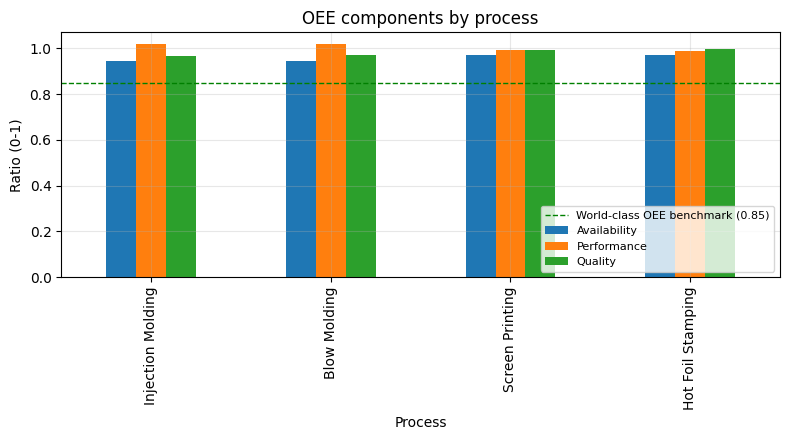

In [2]:
oee_by_process = prod.groupby('Process')[['Availability', 'Performance', 'Quality', 'OEE']].mean().sort_values('OEE')
display(oee_by_process.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
oee_by_process[['Availability', 'Performance', 'Quality']].plot(kind='bar', stacked=False, ax=ax)
ax.axhline(0.85, color='green', linestyle='--', linewidth=1, label='World-class OEE benchmark (0.85)')
ax.set_ylabel('Ratio (0-1)')
ax.set_title('OEE components by process')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{REPORTS}/01_oee_components_by_process.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.2 OEE trend over time (weekly), by process


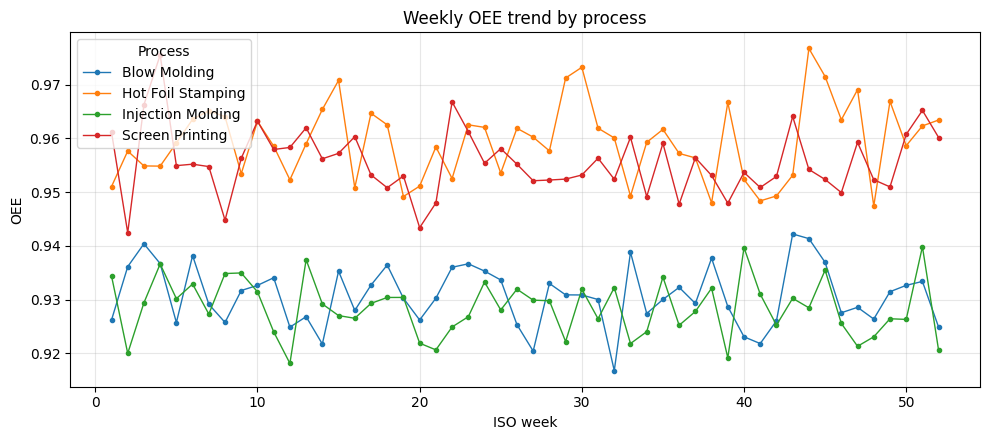

In [3]:
weekly_oee = prod.groupby(['ISOWeek', 'Process'])['OEE'].mean().unstack('Process')

fig, ax = plt.subplots(figsize=(10, 4.5))
weekly_oee.plot(ax=ax, marker='.', linewidth=1)
ax.set_ylabel('OEE')
ax.set_xlabel('ISO week')
ax.set_title('Weekly OEE trend by process')
plt.tight_layout()
plt.savefig(f'{REPORTS}/02_oee_trend_weekly.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.3 Machine-level ranking within each process


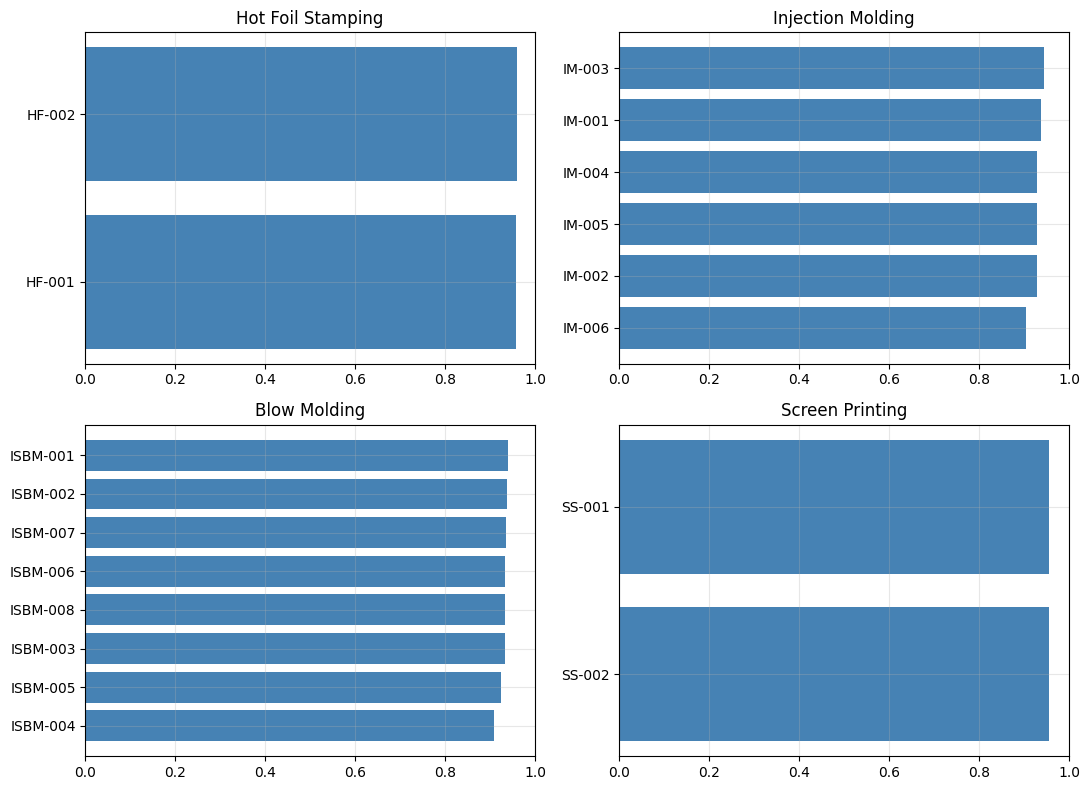

In [4]:
machine_oee = prod.groupby(['Process', 'MachineId'])['OEE'].mean().reset_index().sort_values(['Process', 'OEE'])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, proc in zip(axes.flat, prod['Process'].unique()):
    sub = machine_oee[machine_oee['Process'] == proc]
    ax.barh(sub['MachineId'], sub['OEE'], color='steelblue')
    ax.set_title(proc)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(f'{REPORTS}/03_oee_by_machine.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.4 Downtime Pareto -- planned vs. unplanned, analyzed SEPARATELY

This is a deliberate methodological choice, not just a chart-styling one.
Lumping every stoppage reason into a single Pareto buries the signal that
actually matters: **scheduled** events (mold changes, cleaning, the
shift-3 meal break) are frequent *by design* -- the plant is built to run
that way, and no continuous-improvement project will ever make them go to
zero. **Unplanned** events (mechanical/electrical failures, shortages)
are the ones with real reliability-improvement upside. Reporting them
together always puts a scheduled changeover at the top of the chart and
crowds out the failure that a maintenance team should actually be
chasing.

`PlannedStoppage` (from `fact_downtime_raw`, straight off the MES) is
what we split on.


In [5]:
planned_downtime = downtime[downtime['PlannedStoppage'] == 'Yes']
unplanned_downtime = downtime[downtime['PlannedStoppage'] == 'No']

print(f"Planned stoppages:   {len(planned_downtime):>6,} events, {planned_downtime['DowntimeDurationMin'].sum()/60:>8,.0f} hours")
print(f"Unplanned stoppages: {len(unplanned_downtime):>6,} events, {unplanned_downtime['DowntimeDurationMin'].sum()/60:>8,.0f} hours")


Planned stoppages:   12,345 events,   11,192 hours
Unplanned stoppages:  9,464 events,    5,636 hours


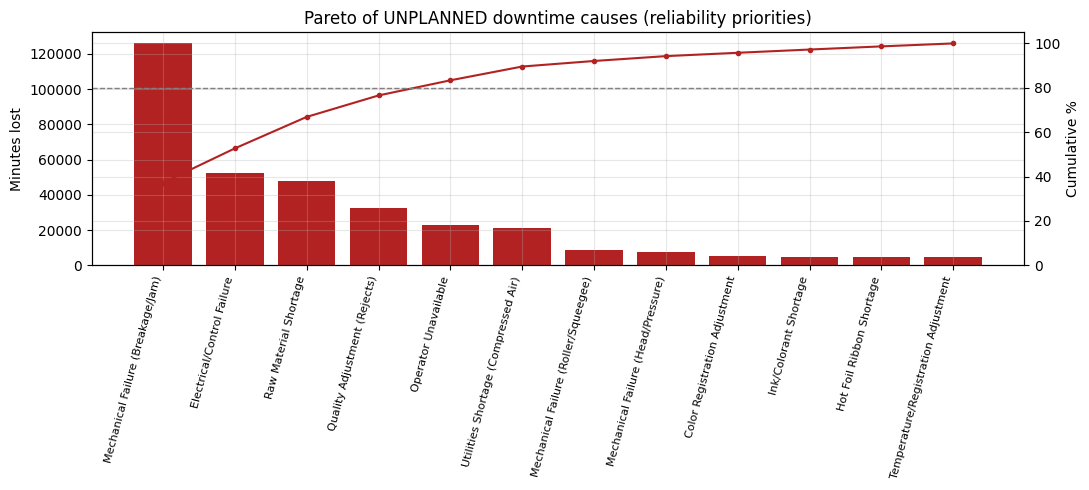

The top 5 of 12 reasons account for ~80% of minutes lost in this category.


In [6]:
def pareto_chart(df, title, filename, color):
    pareto = df.groupby('StoppageReason')['DowntimeDurationMin'].sum().sort_values(ascending=False)
    pareto_pct = (pareto.cumsum() / pareto.sum() * 100)

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(range(len(pareto)), pareto.values, color=color)
    ax1.set_xticks(range(len(pareto)))
    ax1.set_xticklabels(pareto.index, rotation=75, ha='right', fontsize=8)
    ax1.set_ylabel('Minutes lost')
    ax2 = ax1.twinx()
    ax2.plot(range(len(pareto)), pareto_pct.values, color='firebrick', marker='o', markersize=3)
    ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
    ax2.set_ylabel('Cumulative %')
    ax2.set_ylim(0, 105)
    ax1.set_title(title)
    plt.tight_layout()
    plt.savefig(f'{REPORTS}/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

    n_80pct = (pareto_pct <= 80).sum() + 1
    print(f"The top {n_80pct} of {len(pareto)} reasons account for ~80% of minutes lost in this category.")
    return pareto

_ = pareto_chart(unplanned_downtime, 'Pareto of UNPLANNED downtime causes (reliability priorities)',
                  '04a_pareto_downtime_unplanned.png', 'firebrick')


/tmp/ipykernel_658/646170531.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


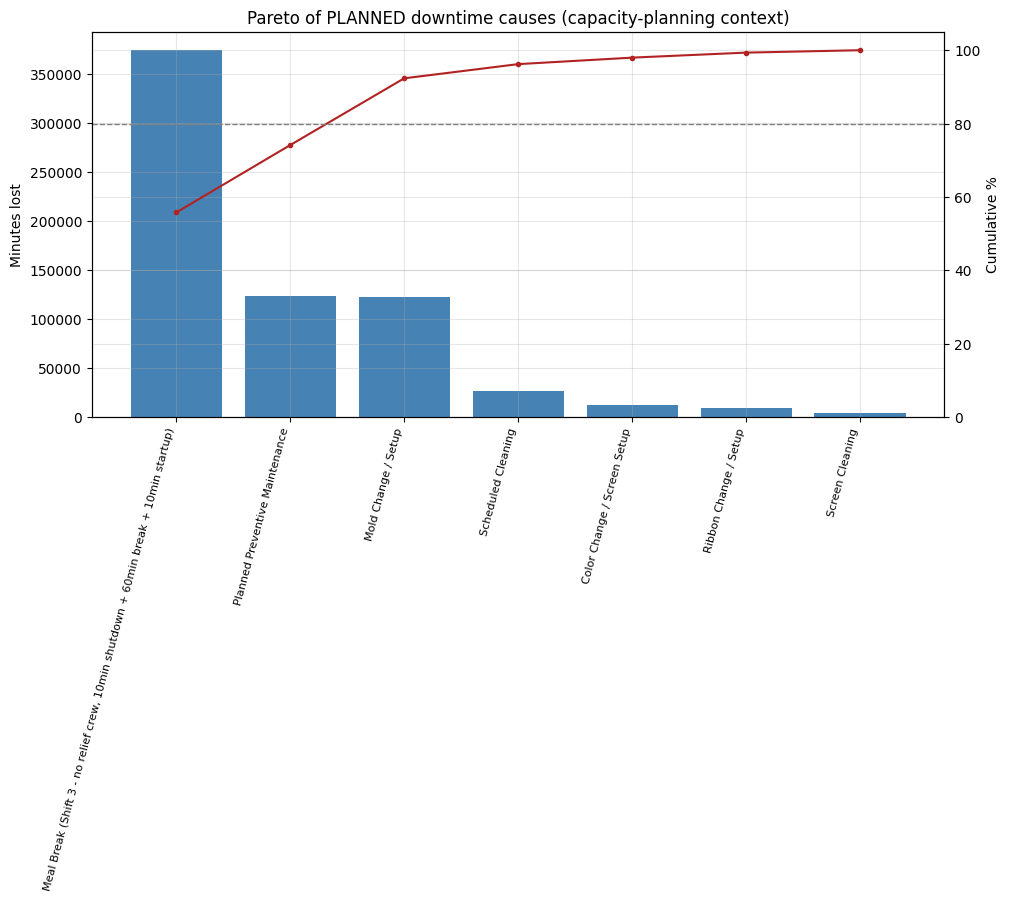

The top 3 of 7 reasons account for ~80% of minutes lost in this category.


In [7]:
_ = pareto_chart(planned_downtime, 'Pareto of PLANNED downtime causes (capacity-planning context)',
                  '04b_pareto_downtime_planned.png', 'steelblue')


The unplanned Pareto is the one worth putting in front of a
continuous-improvement team; the planned Pareto is useful for capacity
planning (how much of the calendar is "spoken for" by design) but ranking
a scheduled meal break as a top "loss" would be misleading.


## 2. Quality Analysis

### 2.1 First Pass Yield (FPY) by process


,FPY
Cap (Injection Molding),93.6
Bottle (Blow Molding),97.0
Ink (Screen Printing),98.2


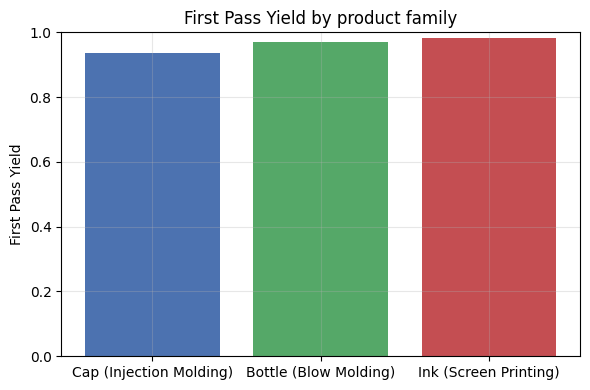

In [8]:
fpy = pd.DataFrame({
    'Cap (Injection Molding)': [(cap_disp['FinalLotDecision'] == 'Approved').mean()],
    'Bottle (Blow Molding)': [(bottle_disp['FinalLotDecision'] == 'Approved').mean()],
    'Ink (Screen Printing)': [(ink_disp['FinalLotDecision'] == 'Approved').mean()],
}).T.rename(columns={0: 'FPY'})
display((fpy * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(fpy.index, fpy['FPY'], color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylim(0, 1)
ax.set_ylabel('First Pass Yield')
ax.set_title('First Pass Yield by product family')
plt.tight_layout()
plt.savefig(f'{REPORTS}/05_fpy_by_product_family.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.2 Pareto of defects (attribute inspections)


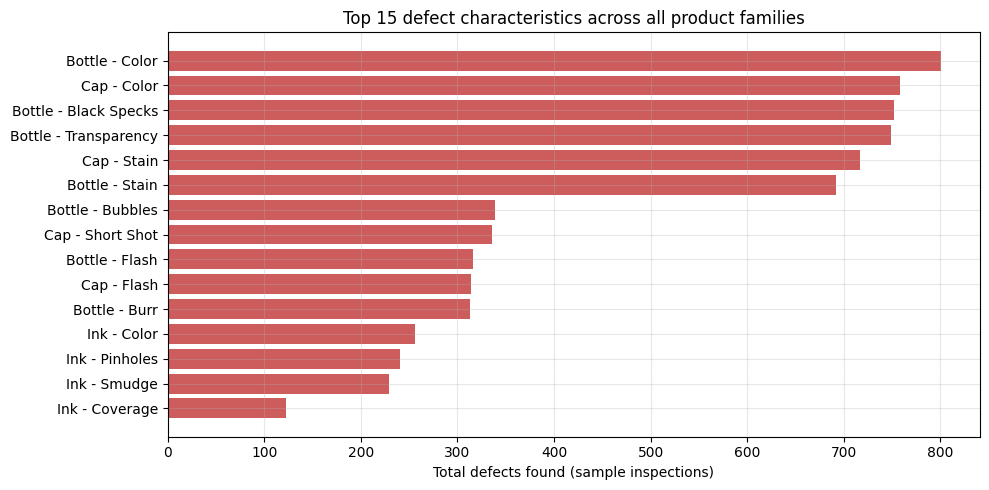

In [9]:
defect_pareto = pd.concat([
    cap_attr.assign(Family='Cap')[['Family', 'Characteristic', 'DefectsFound']],
    bottle_attr.assign(Family='Bottle')[['Family', 'Characteristic', 'DefectsFound']],
    ink_attr.assign(Family='Ink')[['Family', 'Characteristic', 'DefectsFound']],
]).groupby(['Family', 'Characteristic'])['DefectsFound'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{fam} - {char}" for fam, char in defect_pareto.index]
ax.barh(labels[::-1], defect_pareto.values[::-1], color='indianred')
ax.set_xlabel('Total defects found (sample inspections)')
ax.set_title('Top 15 defect characteristics across all product families')
plt.tight_layout()
plt.savefig(f'{REPORTS}/06_pareto_defects.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.3 Process capability (Cp/Cpk) heatmap


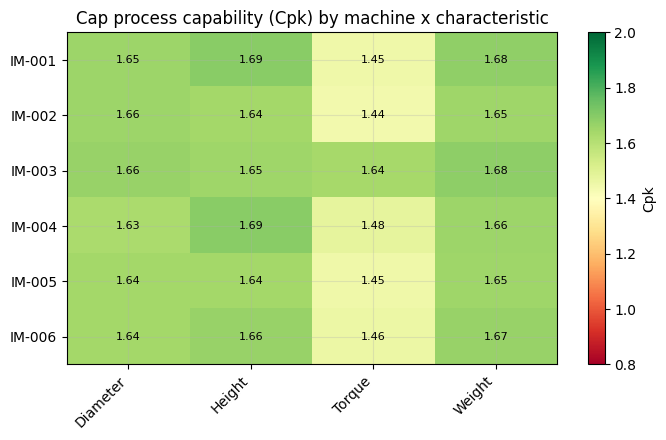

In [10]:
cap_summary = cap_var.drop_duplicates(['Characteristic', 'MachineId', 'MoldId'])
pivot = cap_summary.pivot_table(index='MachineId', columns='Characteristic', values='Cpk', aggfunc='mean')

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0.8, vmax=2.0, aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Cpk')
ax.set_title('Cap process capability (Cpk) by machine x characteristic')
plt.tight_layout()
plt.savefig(f'{REPORTS}/07_cpk_heatmap_cap.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Maintenance Analysis

### 3.1 MTBF and MTTR by machine

Both computed strictly from `UnplannedFailure` events (genuine equipment
failures), excluding planned changeovers/cleaning/preventive maintenance.


,RunTimeHours,FailureCount,MTBFHours,MTTRHours,TheoreticalAvailability
MachineId,,,,,
ISBM-006,6127.43,463,13.23,0.70,0.95
IM-001,6179.30,452,13.67,0.69,0.95
ISBM-001,6126.40,438,13.99,0.70,0.95
ISBM-002,6152.61,438,14.05,0.74,0.95
ISBM-007,6163.76,438,14.07,0.72,0.95
IM-006,6141.44,435,14.12,0.71,0.95
IM-005,6163.40,436,14.14,0.71,0.95
IM-004,6153.50,431,14.28,0.71,0.95
ISBM-004,6160.81,424,14.53,0.76,0.95


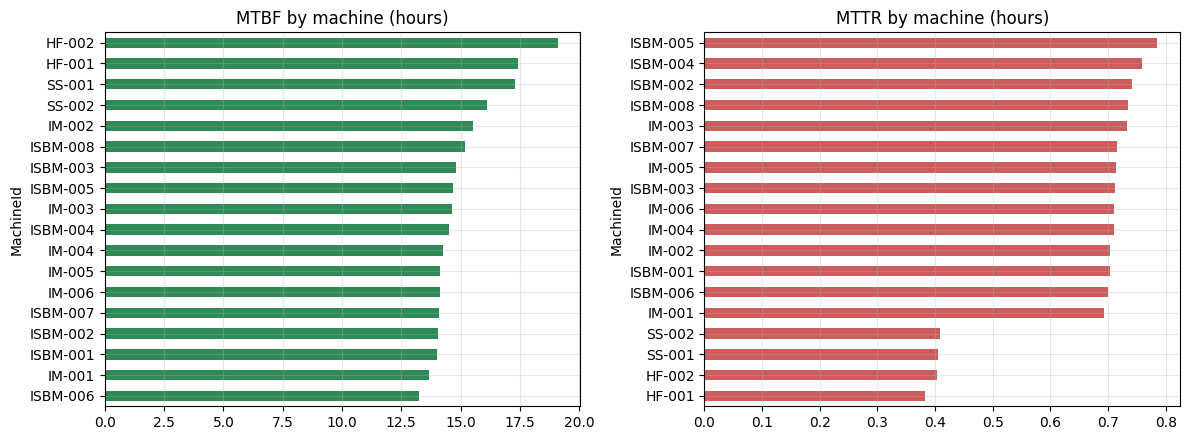

In [11]:
run_time_by_machine = prod.groupby('MachineId')['RunTimeHours'].sum()
failures = downtime[downtime['UnplannedFailure']]
n_failures = failures.groupby('MachineId').size()
mttr = failures.groupby('MachineId')['DowntimeDurationMin'].mean() / 60.0

mtbf_mttr = pd.DataFrame({
    'RunTimeHours': run_time_by_machine,
    'FailureCount': n_failures,
    'MTBFHours': run_time_by_machine / n_failures,
    'MTTRHours': mttr,
}).dropna()
mtbf_mttr['TheoreticalAvailability'] = mtbf_mttr['MTBFHours'] / (mtbf_mttr['MTBFHours'] + mtbf_mttr['MTTRHours'])
display(mtbf_mttr.round(2).sort_values('MTBFHours'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
mtbf_mttr['MTBFHours'].sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('MTBF by machine (hours)')
mtbf_mttr['MTTRHours'].sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('MTTR by machine (hours)')
plt.tight_layout()
plt.savefig(f'{REPORTS}/08_mtbf_mttr_by_machine.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Planned vs unplanned downtime split (time, not just events)


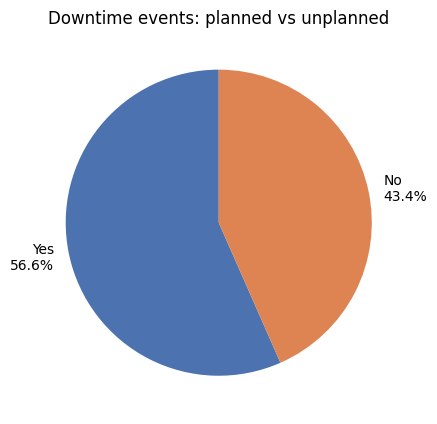

Minutes lost -- planned: 671,524 | unplanned: 338,151


In [12]:
split = downtime['PlannedStoppage'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.pie(split.values, labels=[f"{i}\n{v:.1f}%" for i, v in split.items()], colors=['#4C72B0', '#DD8452'],
       startangle=90)
ax.set_title('Downtime events: planned vs unplanned')
plt.tight_layout()
plt.savefig(f'{REPORTS}/09_downtime_planned_vs_unplanned.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Minutes lost -- planned: {downtime.loc[downtime.PlannedStoppage=='Yes','DowntimeDurationMin'].sum():,.0f} | "
      f"unplanned: {downtime.loc[downtime.PlannedStoppage=='No','DowntimeDurationMin'].sum():,.0f}")


### 3.3 Downtime by process


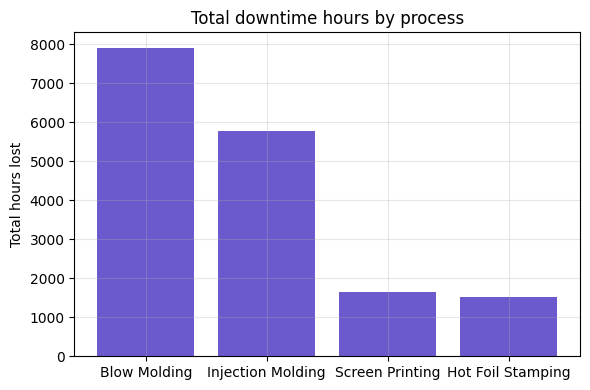

In [13]:
proc_downtime = downtime.groupby('Process')['DowntimeDurationMin'].sum().sort_values(ascending=False) / 60.0

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(proc_downtime.index, proc_downtime.values, color='slateblue')
ax.set_ylabel('Total hours lost')
ax.set_title('Total downtime hours by process')
plt.tight_layout()
plt.savefig(f'{REPORTS}/10_downtime_hours_by_process.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary of this notebook

- Injection Molding/Blow Molding show materially higher OEE than Screen
  Printing/Hot Foil Stamping -- the main driver is Availability, consistent
  with the shift-3 relief-crew rule built into the maintenance simulation.
- The **unplanned** downtime Pareto (not the mixed one) is what should
  drive a reliability-improvement backlog -- it is dominated by mechanical
  failures, not by the scheduled changeovers that top the planned Pareto.
- Cp/Cpk for cap dimensions sit comfortably above 1.33 across the board in
  this simulated dataset -- the process is capable; where FPY still drops,
  the *root cause* is more likely to be attribute defects (visual/AQL)
  than dimensional drift, which the defect Pareto confirms.
- MTBF/MTTR vary meaningfully machine-to-machine within the same process --
  this ranking is where a reliability-centered-maintenance (RCM) review
  should start.

Stage 7 (`13_deep_dive_analysis.ipynb`) ties every domain together
to answer the project's central and auxiliary business questions.
